In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pydicom
from pydicom.pixel_data_handlers.util import apply_voi_lut

In [2]:
DATA_DIR = Path("/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection")
CSV_PATH = DATA_DIR / 'train.csv'
DICOM_DIR = DATA_DIR / 'train'

In [3]:
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} annotation rows across {df.image_id.nunique()} images")
print(df.head())
print(df.isna().sum())

Loaded 67914 annotation rows across 15000 images
                           image_id          class_name  class_id rad_id  \
0  50a418190bc3fb1ef1633bf9678929b3          No finding        14    R11   
1  21a10246a5ec7af151081d0cd6d65dc9          No finding        14     R7   
2  9a5094b2563a1ef3ff50dc5c7ff71345        Cardiomegaly         3    R10   
3  051132a778e61a86eb147c7c6f564dfe  Aortic enlargement         0    R10   
4  063319de25ce7edb9b1c6b8881290140          No finding        14    R10   

    x_min   y_min   x_max   y_max  
0     NaN     NaN     NaN     NaN  
1     NaN     NaN     NaN     NaN  
2   691.0  1375.0  1653.0  1831.0  
3  1264.0   743.0  1611.0  1019.0  
4     NaN     NaN     NaN     NaN  
image_id          0
class_name        0
class_id          0
rad_id            0
x_min         31818
y_min         31818
x_max         31818
y_max         31818
dtype: int64


In [4]:
cls_prev = df.groupby('class_name').size().rename('count').reset_index()
cls_prev['freq'] = cls_prev['count'] / cls_prev['count'].sum()
cls_prev = cls_prev.sort_values('freq', ascending=False)
print(cls_prev)

            class_name  count      freq
8           No finding  31818  0.468504
0   Aortic enlargement   7162  0.105457
3         Cardiomegaly   5427  0.079910
12  Pleural thickening   4842  0.071296
14  Pulmonary fibrosis   4655  0.068543
9          Nodule/Mass   2580  0.037989
7         Lung Opacity   2483  0.036561
11    Pleural effusion   2476  0.036458
10        Other lesion   2203  0.032438
6         Infiltration   1247  0.018361
5                  ILD   1000  0.014725
2        Calcification    960  0.014136
4        Consolidation    556  0.008187
1          Atelectasis    279  0.004108
13        Pneumothorax    226  0.003328


In [5]:
def load_dicom_as_array(dicom_path):
    """Loads the x-ray image dicom file as a numpy array image"""
    dicom = pydicom.dcmread(dicom_path)
    array = apply_voi_lut(dicom.pixel_array, dicom)
    if getattr(dicom, "PhotometricInterpretation", "") == "MONOCHROME1":
        array = np.amax(array) - array
    array = array.astype(np.float32)
    array -= array.min()
    if array.max() > 0:
        array /= array.max()
    return (array * 255).astype(np.uint8)

In [6]:
def plot_image_grid(df, dicom_dir, image_ids=None, n=6, ncols=3,
                     random_state=42, figsize_per_cell=5):
    """ Plots a grid of x-ray images with their diseases bounding boxes annotated"""
    if image_ids is None:
        candidates = df.loc[df.class_name != "No finding", "image_id"].unique()
        rng = np.random.RandomState(random_state)
        image_ids = rng.choice(candidates, size=min(n, len(candidates)), replace=False)

    n = len(image_ids)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_cell * ncols, figsize_per_cell * nrows))
    axes = np.atleast_1d(axes).flatten()

    for ax, image_id in zip(axes, image_ids):
        array = load_dicom_as_array(dicom_dir / f"{image_id}.dicom")
        ax.imshow(array, cmap="gray")

        rows = df[df.image_id == image_id]
        for _, row in rows.iterrows():
            if row.class_name == "No finding" or pd.isna(row.x_min):
                continue  # "No finding" rows carry no box -- nothing to draw
            x_min, y_min, x_max, y_max = row.x_min, row.y_min, row.x_max, row.y_max
            rect = patches.Rectangle(
                (x_min, y_min), x_max - x_min, y_max - y_min,
                linewidth=1.5, edgecolor="red", facecolor="none",
            )
            ax.add_patch(rect)
            ax.text(
                x_min, max(y_min - 5, 0), row.class_name,
                color="red", fontsize=8,
                bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1),
            )

        ax.set_title(image_id, fontsize=9)
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

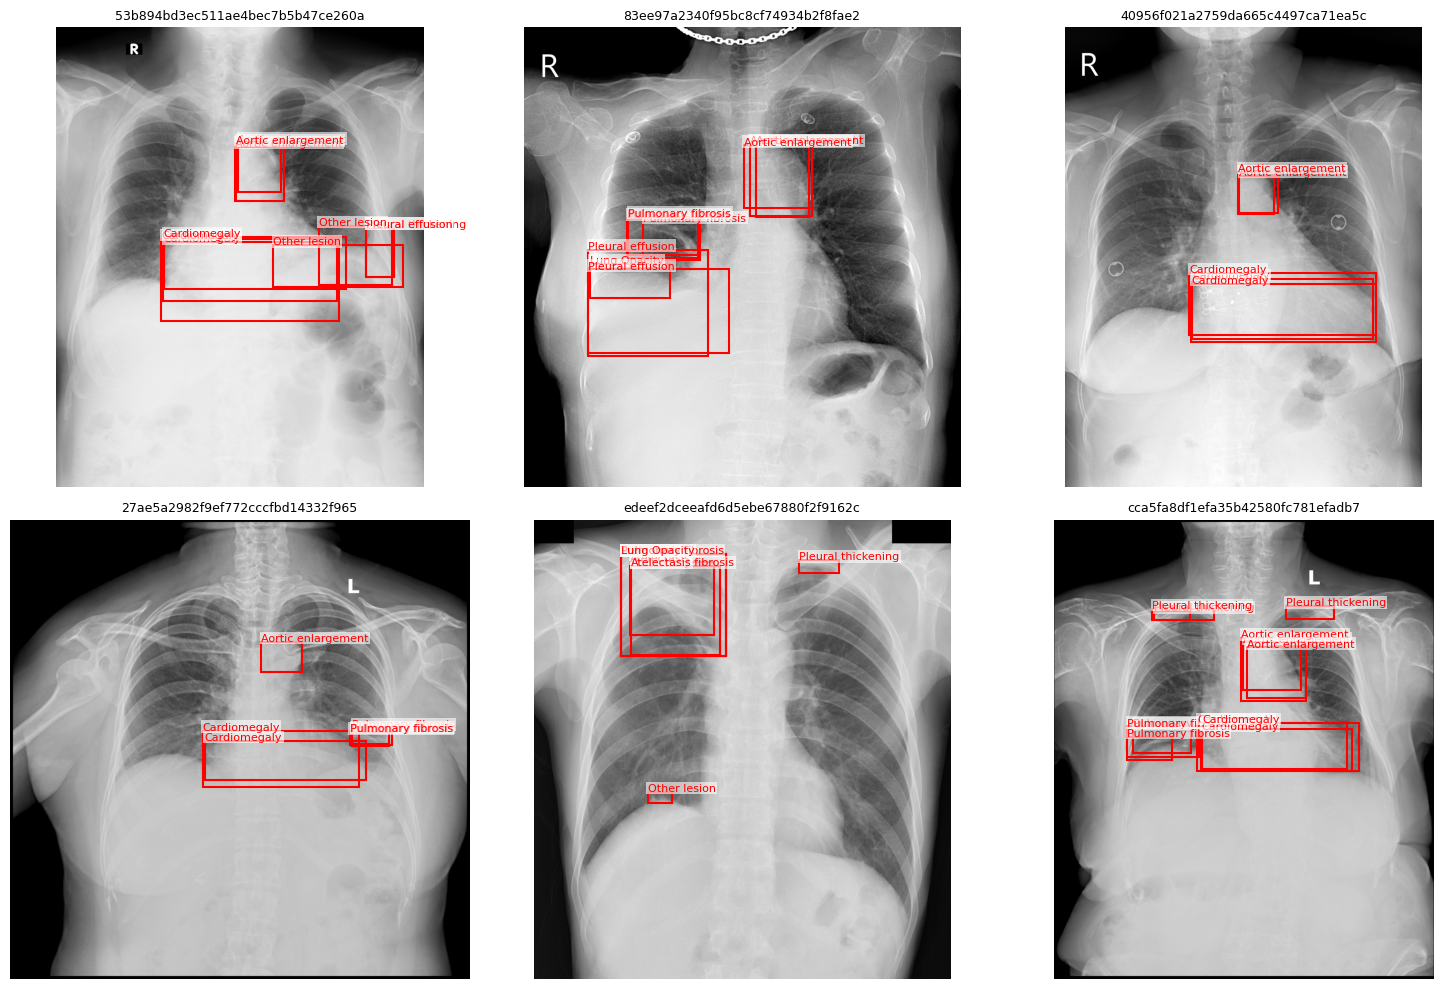

In [7]:
plot_image_grid(df, DICOM_DIR, n=6, ncols=3)